# 01. EDA

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path('data')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'

DTYPES = {
    'offer_depersanalised': 'str',
    'goods_depersanalised': 'str',
    'goods_category_id': 'str',
    'id': 'str',
}

RANDOM_STATE = 42
SAMPLE_SIZE = 100_000
NUMERIC_COLUMNS = ['sum_length', 'attrs+title_score', 'offer_price', 'goods_price']

In [2]:
train = pd.read_csv(TRAIN_PATH, dtype=DTYPES)
test = pd.read_csv(TEST_PATH, dtype=DTYPES)

train_sample = train.sample(n=min(SAMPLE_SIZE, len(train)), random_state=RANDOM_STATE)
test_sample = test.sample(n=min(SAMPLE_SIZE, len(test)), random_state=RANDOM_STATE)

##### Общая структура данных

In [ ]:
print('train:', train.shape)
print('test:', test.shape)

display(train.head())
display(test.head())

train: (2518441, 9)
test: (363835, 8)


,offer_depersanalised,goods_depersanalised,sum_length,attrs+title_score,offer_price,goods_price,goods_category_id,target,id
0,295140,1396793,37,0.027267,1070,NaN,14.0,0,295140$1396793
1,65291,1396586,38,0.050415,698,NaN,14.0,0,65291$1396586
2,39232,1396244,38,0.087280,837,NaN,14.0,0,39232$1396244
3,39232,1396513,38,0.087280,837,NaN,14.0,0,39232$1396513
4,65052,1396237,38,0.079773,1085,NaN,14.0,0,65052$1396237


,offer_depersanalised,goods_depersanalised,sum_length,attrs+title_score,offer_price,goods_price,goods_category_id,id
0,64819,1396468,38,0.046997,368,NaN,14.0,64819$1396468
1,64819,1396235,38,0.046997,368,NaN,14.0,64819$1396235
2,64819,1396318,38,0.046997,368,NaN,14.0,64819$1396318
3,359959,1396281,40,0.060211,634,NaN,14.0,359959$1396281
4,142700,717657,40,0.000370,14924,31840.0,2.0,142700$717657


In [4]:
overview = pd.DataFrame({
    'rows': {'train': len(train), 'test': len(test)},
    'columns': {'train': train.shape[1], 'test': test.shape[1]},
    'memory_mb': {
        'train': train.memory_usage(deep=True).sum() / 1024**2,
        'test': test.memory_usage(deep=True).sum() / 1024**2,
    },
    'duplicate_rows': {
        'train': train.duplicated().sum(),
        'test': test.duplicated().sum(),
    },
    'duplicate_ids': {
        'train': train['id'].duplicated().sum(),
        'test': test['id'].duplicated().sum(),
    },
})

display(overview)

dtypes_summary = pd.DataFrame({
    'train_dtype': train.dtypes.astype(str),
    'test_dtype': test.dtypes.astype(str),
})
display(dtypes_summary)

,rows,columns,memory_mb,duplicate_rows,duplicate_ids
train,2518441,9,712.565092,0,18441
test,363835,8,100.168026,0,0


,train_dtype,test_dtype
attrs+title_score,float64,float64
goods_category_id,object,object
goods_depersanalised,object,object
goods_price,float64,float64
id,object,object
offer_depersanalised,object,object
offer_price,int64,int64
sum_length,int64,int64
target,int64,NaN


##### Пропуски

In [5]:
def missing_table(df, name):
    missing = df.isna().sum()
    return pd.DataFrame({
        'dataset': name,
        'column': missing.index,
        'missing': missing.values,
        'missing_pct': missing.values / len(df),
    })

missing = pd.concat([
    missing_table(train, 'train'),
    missing_table(test, 'test'),
], ignore_index=True)

missing_nonzero = missing[missing['missing'] > 0].sort_values(['dataset', 'missing_pct'], ascending=[True, False])
display(missing_nonzero if not missing_nonzero.empty else missing.head(0))

,dataset,column,missing,missing_pct
14,test,goods_price,58971,0.162082
15,test,goods_category_id,131,0.000360
5,train,goods_price,407287,0.161722
6,train,goods_category_id,833,0.000331


##### Баланс целевого класса

,target,count,share
0,0,2223798,0.883006
1,1,294643,0.116994


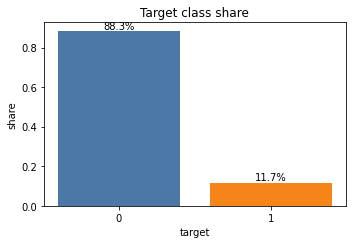

In [6]:
target_summary = (
    train['target']
    .value_counts(dropna=False)
    .rename_axis('target')
    .reset_index(name='count')
    .sort_values('target')
)
target_summary['share'] = target_summary['count'] / len(train)
display(target_summary)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(target_summary['target'].astype(str), target_summary['share'], color=['#4C78A8', '#F58518'])
ax.set_title('Target class share')
ax.set_xlabel('target')
ax.set_ylabel('share')
for i, row in target_summary.reset_index(drop=True).iterrows():
    ax.text(i, row['share'], f"{row['share']:.1%}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

##### Описательная статистика числовых признаков

In [7]:
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
train_numeric_summary = train[NUMERIC_COLUMNS].describe(percentiles=percentiles).T
test_numeric_summary = test[NUMERIC_COLUMNS].describe(percentiles=percentiles).T

display(train_numeric_summary)
display(test_numeric_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
sum_length,2518441.0,587.067173,4.265811e+02,37.000000,83.000000,127.000000,231.000000,507.000000,807.000000,1393.000000,1967.00000,7.829000e+03
attrs+title_score,2518441.0,0.128754,2.644693e-01,0.000031,0.000033,0.000033,0.000036,0.000108,0.052826,0.835449,0.94873,9.975586e-01
offer_price,2518441.0,936296.105196,9.569629e+06,101.000000,251.000000,419.000000,990.000000,2838.000000,9300.000000,60000.000000,370090.00000,1.000001e+08
goods_price,2111154.0,47984.286735,7.939302e+06,101.000000,160.000000,284.000000,665.000000,1780.000000,6516.000000,43070.000000,118490.00000,2.106021e+09


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
sum_length,363835.0,583.423703,4.238701e+02,38.000000,83.000000,126.000000,231.000000,504.000000,800.00000,1386.000000,1957.000000,6.175000e+03
attrs+title_score,363835.0,0.128098,2.642380e-01,0.000032,0.000033,0.000033,0.000035,0.000103,0.05014,0.835938,0.949707,9.970703e-01
offer_price,363835.0,958357.692223,9.683426e+06,101.000000,245.000000,420.000000,982.000000,2832.000000,9321.00000,60525.000000,383900.000000,1.000001e+08
goods_price,304864.0,30895.117892,5.866152e+06,101.000000,160.000000,284.000000,663.000000,1770.000000,6550.00000,42988.000000,117080.000000,1.638016e+09


##### Распределения числовых признаков

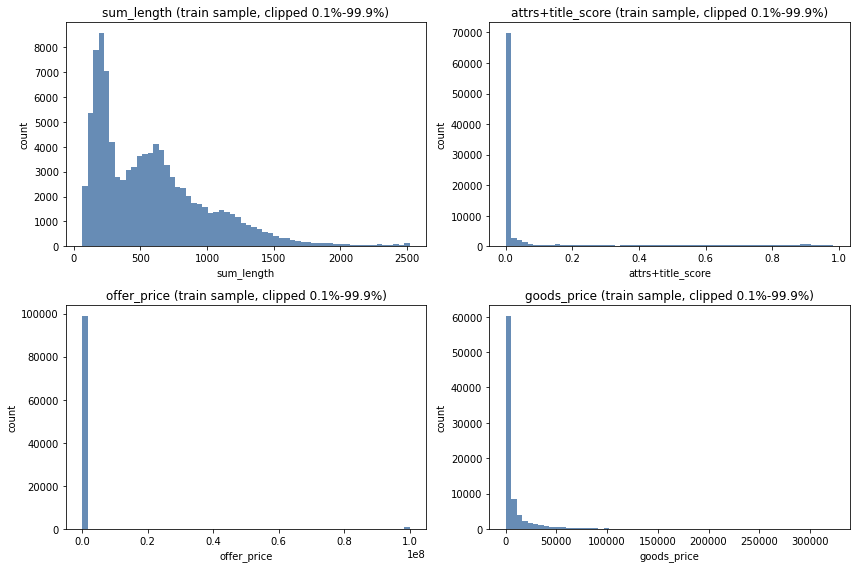

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, column in zip(axes, NUMERIC_COLUMNS):
    values = train_sample[column].dropna()
    if values.empty:
        ax.set_title(f'{column}: no data')
        continue
    low, high = values.quantile([0.001, 0.999])
    clipped = values.clip(low, high)
    ax.hist(clipped, bins=60, color='#4C78A8', alpha=0.85)
    ax.set_title(f'{column} (train sample, clipped 0.1%-99.9%)')
    ax.set_xlabel(column)
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()

##### Числовые признаки по классам

sum_length                                          attrs+title_score  \
            count        mean median         std min   max             count   
target                                                                         
0         2223798  562.183557  475.0  420.047463  37  7829           2223798   
1          294643  774.874574  703.0  428.691599  54  5438            294643   

                                      ... offer_price                     \
            mean    median       std  ...      median           std  min   
target                                ...                                  
0       0.060111  0.000053  0.168596  ...      2837.0  9.488824e+06  101   
1       0.646828  0.741699  0.281688  ...      2850.0  1.015801e+07  101   

                  goods_price                                             \
              max       count          mean  median           std    min   
target                                                                     
0       100000100     1820872  53825.103324  1700.0  8.548727e+06  101.0   
1       100000100      290282  11346.192107  2360.0  2.790632e+04  102.0   

                      
                 max  
target                
0       2.106021e+09  
1       6.300990e+05  

[2 rows x 24 columns]

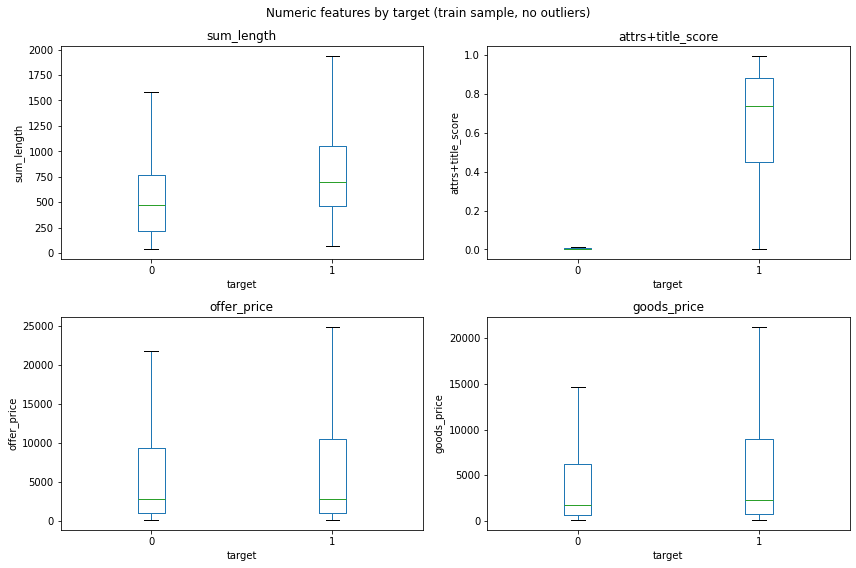

In [9]:
by_target_summary = train.groupby('target')[NUMERIC_COLUMNS].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
display(by_target_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, column in zip(axes, NUMERIC_COLUMNS):
    train_sample.boxplot(column=column, by='target', ax=ax, showfliers=False, grid=False)
    ax.set_title(column)
    ax.set_xlabel('target')
    ax.set_ylabel(column)

fig.suptitle('Numeric features by target (train sample, no outliers)')
plt.tight_layout()
plt.show()

##### Связь `attrs+title_score` с target

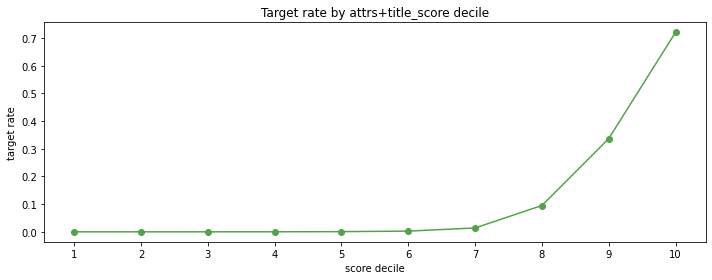

In [10]:
score_frame = train[['attrs+title_score', 'target']].dropna().copy()
score_frame['score_decile'] = pd.qcut(score_frame['attrs+title_score'], q=10, duplicates='drop')

score_deciles = (
    score_frame
    .groupby('score_decile', observed=False)
    .agg(rows=('target', 'size'), target_rate=('target', 'mean'), score_min=('attrs+title_score', 'min'), score_max=('attrs+title_score', 'max'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(score_deciles) + 1), score_deciles['target_rate'], marker='o', color='#54A24B')
ax.set_title('Target rate by attrs+title_score decile')
ax.set_xlabel('score decile')
ax.set_ylabel('target rate')
ax.set_xticks(range(1, len(score_deciles) + 1))
plt.tight_layout()
plt.show()

##### Анализ цен и производных EDA-признаков

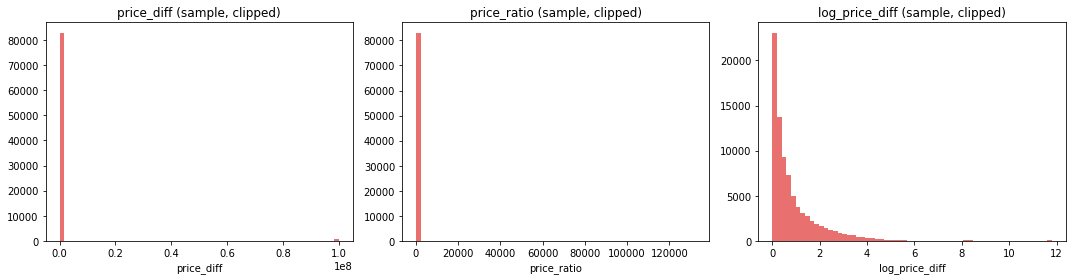

In [11]:
price_frame = train[['offer_price', 'goods_price', 'target']].copy()
price_frame['price_diff'] = (price_frame['offer_price'] - price_frame['goods_price']).abs()
price_frame['price_ratio'] = price_frame['offer_price'] / (price_frame['goods_price'] + 1)
price_frame['log_price_diff'] = (np.log1p(price_frame['offer_price']) - np.log1p(price_frame['goods_price'])).abs()

price_quality = pd.DataFrame({
    'metric': ['offer_price_missing', 'goods_price_missing', 'offer_price_zero_or_negative', 'goods_price_zero_or_negative'],
    'count': [
        price_frame['offer_price'].isna().sum(),
        price_frame['goods_price'].isna().sum(),
        (price_frame['offer_price'] <= 0).sum(),
        (price_frame['goods_price'] <= 0).sum(),
    ],
})
price_quality['share'] = price_quality['count'] / len(price_frame)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, ['price_diff', 'price_ratio', 'log_price_diff']):
    values = price_frame.loc[train_sample.index, column].replace([np.inf, -np.inf], np.nan).dropna()
    low, high = values.quantile([0.001, 0.999])
    ax.hist(values.clip(low, high), bins=60, color='#E45756', alpha=0.85)
    ax.set_title(f'{column} (sample, clipped)')
    ax.set_xlabel(column)
plt.tight_layout()
plt.show()